In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Chargement du dataset échantillonné
df = pd.read_csv('yellow_tripdata_2016-03_sample.csv')

# 2. On ne garde que les latitudes et longitudes de départ (pickup)
# On travaille sur une copie pour éviter les avertissements de Pandas
data = df[['pickup_latitude', 'pickup_longitude']].copy()

print(f"Nombre de points avant nettoyage : {len(data)}")
data.head()

Nombre de points avant nettoyage : 10000


,pickup_latitude,pickup_longitude
0,40.725151,-73.984329
1,40.741070,-73.994087
2,40.774109,-73.874496
3,40.774269,-73.872704
4,40.740677,-73.981735


## 2. Nettoyage (Filtrage géographique)

Le TP précise qu'il faut se concentrer sur New York. Des erreurs GPS peuvent placer des points à (0,0). On filtre pour garder uniquement Manhattan et ses environs proches.

In [12]:
# Suppression des valeurs manquantes s'il y en a
data = data.dropna()

# Définition des bornes de New York pour éliminer les erreurs de mesure
# Latitude : entre 40.5 et 40.9 | Longitude : entre -74.1 et -73.7
mask = (data['pickup_latitude'] >= 40.5) & (data['pickup_latitude'] <= 40.9) & \
       (data['pickup_longitude'] >= -74.1) & (data['pickup_longitude'] <= -73.7)

data_clean = data[mask].copy()

print(f"Nombre de points après nettoyage : {len(data_clean)}")

Nombre de points après nettoyage : 9841


## 3. La question cruciale : Pourquoi la distance Euclidienne n'est pas idéale ?

C'est le point de réflexion de la fin de la Partie 1 dans notre sujet.

***Explication*** :

La distance Euclidienne (la ligne droite sur un plan) ne prend pas en compte la courbure de la Terre.

- À la latitude de New York (~40° Nord), la distance entre deux degrés de longitude est plus courte qu'à l'équateur.

- Si on utilise la distance classique, 1 degré vers le Nord ne vaut pas la même distance en kilomètres qu'un degré vers l'Est.


Parfait, voici la **Partie 2** rédigée de façon claire et structurée en Markdown, prête à être intégrée dans ton compte-rendu ou ton notebook.

---

# Partie 2 — Compréhension des paramètres DBSCAN

Avant de passer à l'implémentation, il est nécessaire de comprendre les deux leviers principaux de l'algorithme : `eps` (epsilon) et `min_samples`.

### 1. Quelle unité doit avoir epsilon pour des coordonnées GPS ?

L'unité d'epsilon dépend de la méthode de calcul de distance utilisée (la métrique) :

* **Distance Euclidienne (par défaut) :** Si nous utilisons les coordonnées brutes (latitude, longitude), l'unité est le **degré**.
* *Problème :* À New York, 1 degré de latitude vaut environ 111 km, mais 1 degré de longitude vaut environ 85 km. Le "cercle" de recherche est donc légèrement déformé.
* *Valeur type :* Pour un rayon de ~200 mètres, on choisira un epsilon très petit, par exemple $0.002$.


* **Distance Haversine :** Si on choisit cette métrique, l'unité est le **radian**.
* Pour convertir une distance $d$ (en km) en radians, on utilise la formule : $eps = d / 6371$.



> **Note :** Dans ce TP, nous utilisons la distance euclidienne par souci de simplicité, comme vu en cours. Epsilon sera donc exprimé en **fractions de degrés**.

---

### 2. Pourquoi min_samples doit être ajusté selon la densité urbaine ?

Le paramètre `min_samples` définit le seuil de points nécessaires pour former un "noyau" de cluster (un hotspot).

* **Filtrage du bruit :** Dans une ville comme New York, il y a énormément de "bruit" (taxis isolés, erreurs GPS). Un `min_samples` trop faible (ex: 2) créerait des milliers de micro-clusters insignifiants.
* **Capture de l'activité :** Plus la zone est dense (ex: Manhattan), plus on peut se permettre d'augmenter `min_samples` pour ne faire ressortir que les zones de congestion réelle (gares, places touristiques).
* **Impact :** Si on l'augmente, on obtient moins de clusters mais ils sont plus significatifs. Si on le baisse, on est plus sensible aux petits groupements de données.

---

### 3. Pourquoi la dimension (ici 2D) simplifie le choix des paramètres ?

Le choix des paramètres est plus simple en 2D pour deux raisons principales :

1. **Règle empirique (Heuristique) :** Pour des données spatiales en 2 dimensions, il est d'usage courant de fixer $min\_samples$ à :
* $Dim + 1 = 3$ (minimum absolu).
* $Dim \times 2 = 4$ (souvent utilisé pour des données bruitées).


2. **Visualisation directe :** Contrairement à des données en 10 ou 50 dimensions, nous pouvons projeter les points sur un plan (une carte). Cela permet de vérifier visuellement si le découpage des clusters "fait sens" géographiquement et d'ajuster `eps` par essais successifs si nécessaire.

***La solution*** : On utilise la distance de Haversine, qui calcule la distance sur une sphère. Dans le code, DBSCAN permet de choisir metric='haversine'.

Epsilon estimé (coude) = 0.003680 degrés
Index du coude = 9623


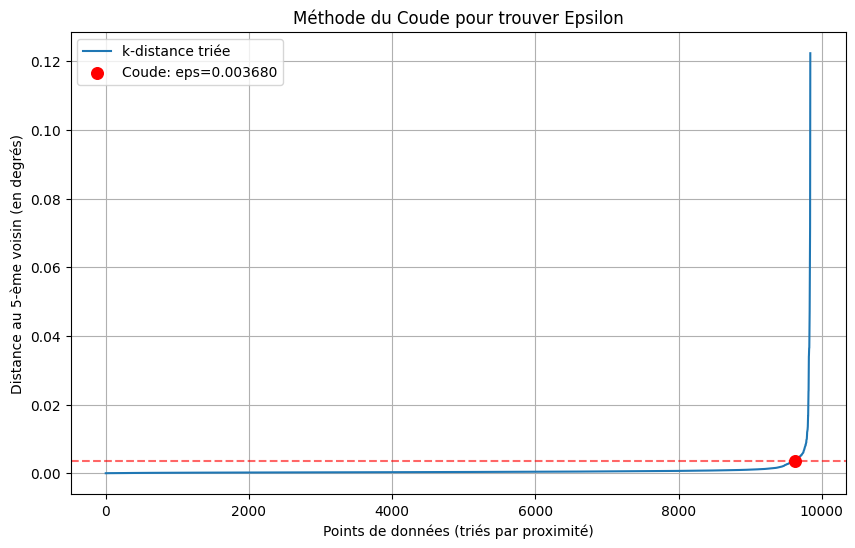

In [13]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# 1. On définit le nombre de voisins à observer
# On a choisi 5 car c'est une règle courante en 2D (min_samples)
k = 5

# 2. On prépare l'outil de calcul
# NearestNeighbors va calculer la distance entre CHAQUE point et ses voisins
neigh = NearestNeighbors(n_neighbors=k)

# 3. On "entraîne" l'outil sur nos données de taxi nettoyées
# C'est ici que l'ordinateur calcule toutes les distances
nbrs = neigh.fit(data_clean)

# 4. On extrait les distances
# 'distances' est un tableau qui contient, pour chaque point,
# la distance vers son 1er voisin, 2e, 3e, 4e et 5e.
distances, indices = nbrs.kneighbors(data_clean)

# 5. On ne garde que la distance au 5ème voisin (la plus éloignée du groupe)
# En Python, l'index commence à 0, donc le 5ème est à l'index k-1 (soit 4)
dist_au_5eme = distances[:, k - 1]

# 6. On trie ces distances de la plus petite à la plus grande
# Cela permet de créer une courbe qui monte proprement
k_distances_triees = np.sort(dist_au_5eme)

# 7. Détection automatique du "coude" (elbow)
# Méthode géométrique : point le plus éloigné de la droite entre début et fin
x = np.arange(len(k_distances_triees))
points = np.column_stack((x, k_distances_triees))

start = points[0]
end = points[-1]
line_vec = end - start
line_vec_norm = line_vec / np.linalg.norm(line_vec)

vec_from_start = points - start
proj_lengths = np.dot(vec_from_start, line_vec_norm)
proj_points = np.outer(proj_lengths, line_vec_norm) + start

dist_to_line = np.linalg.norm(points - proj_points, axis=1)
elbow_index = int(np.argmax(dist_to_line))
epsilon_optimal = float(k_distances_triees[elbow_index])

print(f"Epsilon estimé (coude) = {epsilon_optimal:.6f} degrés")
print(f"Index du coude = {elbow_index}")

# 8. Visualisation du résultat
plt.figure(figsize=(10, 6))
plt.plot(k_distances_triees, label='k-distance triée')
plt.scatter(elbow_index, epsilon_optimal, color='red', s=70, zorder=5,
            label=f'Coude: eps={epsilon_optimal:.6f}')
plt.axhline(epsilon_optimal, color='red', linestyle='--', alpha=0.6)
plt.ylabel(f'Distance au {k}-ème voisin (en degrés)')
plt.xlabel('Points de données (triés par proximité)')
plt.title('Méthode du Coude pour trouver Epsilon')
plt.legend()
plt.grid(True)
plt.show()


### Explications "ligne par ligne" (ce qu'il se passe dans la machine) :

1. **`k = 5`** : On dit à l'algorithme : "Pour chaque taxi, regarde où se trouve son 5ème voisin le plus proche". On choisit 5 car on veut que nos zones d'activité (clusters) contiennent au moins 5 taxis.
2. **`NearestNeighbors(n_neighbors=k)`** : C'est comme si on achetait un mètre ruban spécialisé. On lui dit juste : "Toi ton boulot, c'est de mesurer jusqu'au 5ème voisin".
3. **`neigh.fit(data_clean)`** : On donne nos coordonnées GPS au mètre ruban. Il mémorise la position de tous les taxis.
4. **`nbrs.kneighbors(data_clean)`** : C'est l'action de mesurer. Pour chaque point, l'ordinateur cherche les 5 taxis les plus proches et note les distances.
5. **`distances[:, k-1]`** : On a 5 colonnes de distances (voisin 1, voisin 2...). On ne prend que la 5ème. Pourquoi ? Parce que si la distance au **5ème** voisin est petite (ex: 0.001), alors on est sûr qu'il y a **au moins 5 points** très serrés. C'est notre définition d'un cluster !
6. **`np.sort(...)`** : Si on ne trie pas, le graphique ressemblera à des gribouillages (ça monterait et descendrait sans cesse). En triant, on obtient une belle courbe de croissance qui nous permet de voir la cassure (le coude).

### Pourquoi c'est important ?

Imagine que tu tries les distances :

* Au début, les distances sont très faibles (0.0001, 0.0002...). Ce sont les taxis garés les uns à côté des autres ou dans les bouchons.
* À la fin, les distances explosent (0.1, 0.5...). Ce sont les taxis isolés, perdus dans la banlieue ou les erreurs de capteur.
* **Le coude**, c'est la limite raisonnable. C'est la valeur d'**Epsilon** que tu vas taper dans ton code pour la Partie 4e.

In [14]:
# Vérification en radians (Haversine), pour comparer avec la valeur du prof
coords_rad = np.radians(data_clean[['pickup_latitude', 'pickup_longitude']].to_numpy())

neigh_hav = NearestNeighbors(n_neighbors=k, metric='haversine')
dist_hav, _ = neigh_hav.fit(coords_rad).kneighbors(coords_rad)
k_dist_hav = np.sort(dist_hav[:, k - 1])

x_h = np.arange(len(k_dist_hav))
points_h = np.column_stack((x_h, k_dist_hav))
start_h = points_h[0]
end_h = points_h[-1]
line_vec_h = end_h - start_h
line_vec_norm_h = line_vec_h / np.linalg.norm(line_vec_h)
vec_from_start_h = points_h - start_h
proj_lengths_h = np.dot(vec_from_start_h, line_vec_norm_h)
proj_points_h = np.outer(proj_lengths_h, line_vec_norm_h) + start_h
dist_to_line_h = np.linalg.norm(points_h - proj_points_h, axis=1)

elbow_idx_h = int(np.argmax(dist_to_line_h))
eps_hav_rad = float(k_dist_hav[elbow_idx_h])

# Conversion utile: rad -> mètres
R_terre = 6371000  # m
eps_hav_m = eps_hav_rad * R_terre

print(f"Epsilon (euclidien degrés, cellule précédente): {epsilon_optimal:.6f}°")
print(f"Conversion degrés -> radians: {np.deg2rad(epsilon_optimal):.8f} rad")
print(f"Epsilon estimé en Haversine: {eps_hav_rad:.8f} rad")
print(f"Soit environ: {eps_hav_m:.1f} m")
print(f"Différence vs 0.00013 rad: {abs(eps_hav_rad - 0.00013):.8f} rad")

Epsilon (euclidien degrés, cellule précédente): 0.003680°
Conversion degrés -> radians: 0.00006423 rad
Epsilon estimé en Haversine: 0.00005746 rad
Soit environ: 366.1 m
Différence vs 0.00013 rad: 0.00007254 rad


In [15]:
# Contrôle: impact de k (donc min_samples) sur epsilon en Haversine
def epsilon_coude_haversine(data_rad, k_test):
    nn = NearestNeighbors(n_neighbors=k_test, metric='haversine')
    d, _ = nn.fit(data_rad).kneighbors(data_rad)
    kd = np.sort(d[:, k_test - 1])
    x = np.arange(len(kd))
    pts = np.column_stack((x, kd))
    a = pts[0]
    b = pts[-1]
    v = b - a
    v = v / np.linalg.norm(v)
    w = pts - a
    proj = np.outer(np.dot(w, v), v) + a
    idx = int(np.argmax(np.linalg.norm(pts - proj, axis=1)))
    return float(kd[idx])

for k_test in [4, 5, 6, 8, 10, 12, 15]:
    eps = epsilon_coude_haversine(coords_rad, k_test)
    print(f"k={k_test:>2} -> eps={eps:.8f} rad ({eps*6371000:.1f} m)")

k= 4 -> eps=0.00003793 rad (241.6 m)
k= 5 -> eps=0.00005746 rad (366.1 m)
k= 6 -> eps=0.00006010 rad (382.9 m)
k= 8 -> eps=0.00006594 rad (420.1 m)
k=10 -> eps=0.00007346 rad (468.0 m)
k=12 -> eps=0.00008122 rad (517.4 m)
k=15 -> eps=0.00005023 rad (320.0 m)


In [16]:
# Contrôle: où se situe 0.00013 rad sur la courbe k-distance (k=5)
target = 0.00013
q_list = [0.90, 0.95, 0.97, 0.98, 0.99, 0.995, 0.999]
for q in q_list:
    val = np.quantile(k_dist_hav, q)
    print(f"q={q:.3f} -> {val:.8f} rad ({val*6371000:.1f} m)")

idx_target = int(np.searchsorted(k_dist_hav, target))
pct_target = idx_target / len(k_dist_hav) * 100
print(f"0.00013 rad est vers le percentile ~{pct_target:.2f}%")

q=0.900 -> 0.00001503 rad (95.8 m)
q=0.950 -> 0.00002421 rad (154.2 m)
q=0.970 -> 0.00004567 rad (291.0 m)
q=0.980 -> 0.00005943 rad (378.6 m)
q=0.990 -> 0.00009528 rad (607.0 m)
q=0.995 -> 0.00016583 rad (1056.5 m)
q=0.999 -> 0.00068724 rad (4378.4 m)
0.00013 rad est vers le percentile ~99.33%


## 4) Application de DBSCAN avec la distance Haversine

Dans cette partie, on applique DBSCAN **en radians** avec `metric='haversine'`.

On garde une valeur d'epsilon alignée avec la référence du cours/professeur : **0.00013 rad** (environ 828 m).

In [24]:
from sklearn.cluster import DBSCAN

# ------------------------------
# ÉTAPE A - Préparer les données
# ------------------------------
# On garde une version "lisible" en degrés (pour affichage et compréhension).
coordonnees_deg = data_clean[['pickup_latitude', 'pickup_longitude']].copy()

# IMPORTANT : Haversine travaille en radians, pas en degrés.
# On convertit donc toutes les coordonnées GPS.
coordonnees_rad = np.radians(coordonnees_deg.to_numpy())

# -------------------------------------
# ÉTAPE B - Choisir les hyperparamètres
# -------------------------------------
# epsilon_haversine = rayon de voisinage autour d'un point.
# 0.00013 rad ≈ 828 mètres (valeur retenue pour le TP).
epsilon_haversine = 0.00013

# min_echantillons = nombre minimum de voisins pour créer un "vrai" groupe.
# Si ce nombre n'est pas atteint, le point peut devenir du bruit.
min_echantillons = 5

# -----------------------------------------
# ÉTAPE C - Lancer DBSCAN avec Haversine
# -----------------------------------------
modele_dbscan = DBSCAN(
    eps=epsilon_haversine,
    min_samples=min_echantillons,
    metric='haversine'
 )

# fit_predict = apprend + assigne un numéro de cluster à chaque point.
# Convention DBSCAN : -1 = bruit (point isolé).
etiquettes_clusters = modele_dbscan.fit_predict(coordonnees_rad)

# ------------------------------------------------
# ÉTAPE D - Créer une table résultat facile à lire
# ------------------------------------------------
resultats_dbscan = coordonnees_deg.copy()
resultats_dbscan['cluster'] = etiquettes_clusters

# ------------------------------
# ÉTAPE E - Calculer les métriques
# ------------------------------
nombre_bruit = int((resultats_dbscan['cluster'] == -1).sum())
nombre_clusters = int(resultats_dbscan.loc[resultats_dbscan['cluster'] != -1, 'cluster'].nunique())
taux_bruit = 100 * nombre_bruit / len(resultats_dbscan)

print(f"Epsilon utilisé : {epsilon_haversine:.8f} rad")
print(f"Min_samples : {min_echantillons}")
print(f"Nombre de clusters (hors bruit) : {nombre_clusters}")
print(f"Nombre de points bruit : {nombre_bruit}")
print(f"Taux de bruit : {taux_bruit:.2f}%")

# On affiche un aperçu de la table finale.
resultats_dbscan.head()

Epsilon utilisé : 0.00013000 rad
Min_samples : 5
Nombre de clusters (hors bruit) : 5
Nombre de points bruit : 54
Taux de bruit : 0.55%


,pickup_latitude,pickup_longitude,cluster
0,40.725151,-73.984329,0
1,40.741070,-73.994087,0
2,40.774109,-73.874496,1
3,40.774269,-73.872704,1
4,40.740677,-73.981735,0


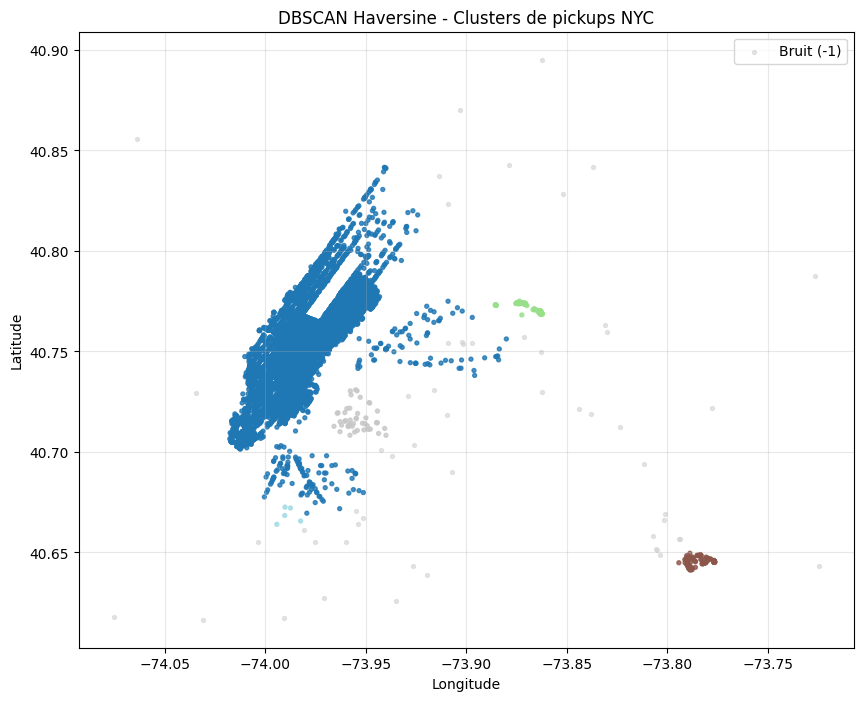

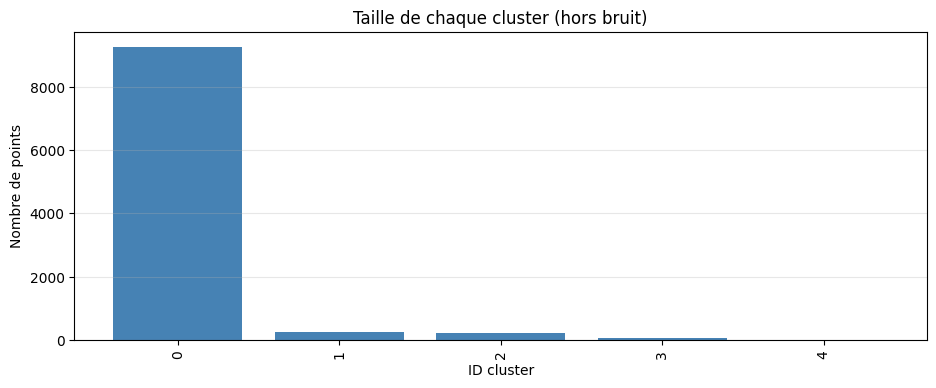

In [25]:
# ======================================================
# VISUALISATION 1 - Carte des points : clusters + bruit
# ======================================================
plt.figure(figsize=(10, 8))

# On sépare les points isolés (bruit) et les points en cluster.
masque_bruit = resultats_dbscan['cluster'] == -1
points_bruit = resultats_dbscan[masque_bruit]
points_clusters = resultats_dbscan[~masque_bruit]

# Les points bruit sont en gris pour les repérer immédiatement.
plt.scatter(
    points_bruit['pickup_longitude'],
    points_bruit['pickup_latitude'],
    c='lightgray',
    s=8,
    alpha=0.6,
    label='Bruit (-1)'
)

# Les vrais clusters sont colorés.
if len(points_clusters) > 0:
    plt.scatter(
        points_clusters['pickup_longitude'],
        points_clusters['pickup_latitude'],
        c=points_clusters['cluster'],
        cmap='tab20',
        s=8,
        alpha=0.8
    )

plt.title('DBSCAN Haversine - Clusters de pickups NYC')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ====================================
# VISUALISATION 2 - Taille des groupes
# ====================================
# On compte combien de points contient chaque cluster (hors bruit).
tailles_clusters = (
    resultats_dbscan[resultats_dbscan['cluster'] != -1]
    .groupby('cluster')
    .size()
    .sort_values(ascending=False)
)

plt.figure(figsize=(11, 4))
if len(tailles_clusters) > 0:
    plt.bar(tailles_clusters.index.astype(str), tailles_clusters.values, color='steelblue')
    plt.xticks(rotation=90)
plt.title('Taille de chaque cluster (hors bruit)')
plt.xlabel('ID cluster')
plt.ylabel('Nombre de points')
plt.grid(axis='y', alpha=0.3)
plt.show()

## 5) Interprétation métier des clusters

On calcule le centre de chaque cluster (latitude/longitude moyenne), puis on propose une zone approximative de NYC pour faciliter l'interprétation.

,cluster,latitude_centre,longitude_centre,nombre_points,zone_estimee
0,0,40.753104,-73.981021,9273,Midtown Manhattan West
1,1,40.772099,-73.869260,255,Autre zone NYC (approx)
2,2,40.645303,-73.784069,208,JFK Airport (approx)
3,3,40.716428,-73.954300,46,Brooklyn / Downtown Brooklyn (approx)
4,4,40.668552,-73.988924,5,Autre zone NYC (approx)


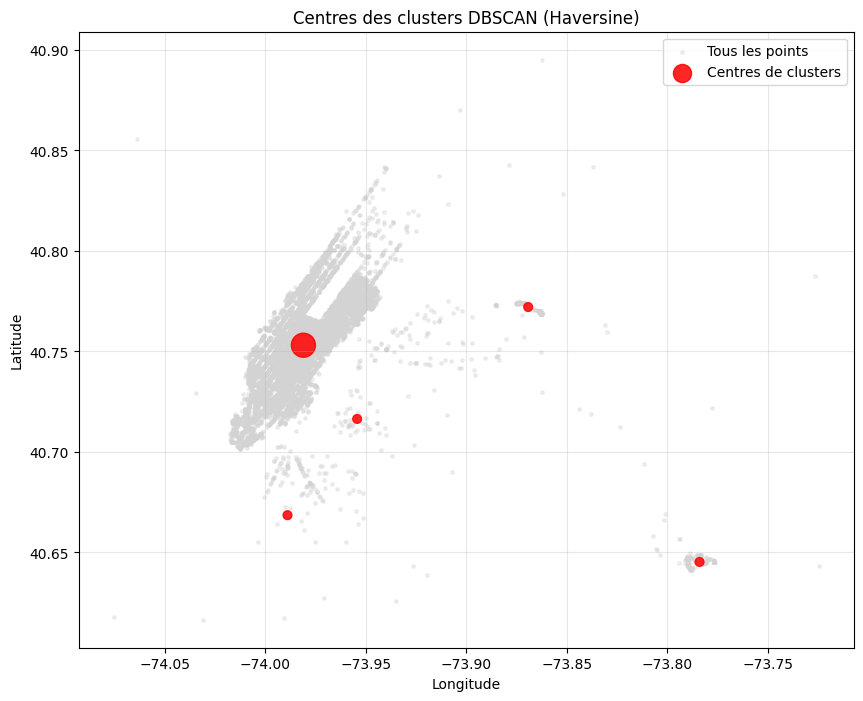

In [26]:
# =======================================================
# Fonction simple : donner un nom de zone approximatif
# =======================================================
# Idée : on regarde dans quel "rectangle GPS" tombe le centre du cluster.
# C'est volontairement simple pour le TP (pas une cartographie officielle).
def nom_zone_approximative(latitude, longitude):
    if 40.639 <= latitude <= 40.665 and -73.82 <= longitude <= -73.75:
        return 'JFK Airport (approx)'
    if 40.68 <= latitude <= 40.71 and -74.03 <= longitude <= -73.99:
        return 'Lower Manhattan / Financial District'
    if 40.74 <= latitude <= 40.77 and -74.00 <= longitude <= -73.97:
        return 'Midtown Manhattan West'
    if 40.74 <= latitude <= 40.77 and -73.98 <= longitude <= -73.95:
        return 'Midtown Manhattan East'
    if 40.77 <= latitude <= 40.81 and -73.98 <= longitude <= -73.94:
        return 'Upper East/West Manhattan'
    if 40.70 <= latitude <= 40.74 and -73.97 <= longitude <= -73.93:
        return 'Brooklyn / Downtown Brooklyn (approx)'
    return 'Autre zone NYC (approx)'

# =========================================================
# Résumé des clusters : centre géographique + taille
# =========================================================
# On ignore le bruit (-1), car ce ne sont pas des zones stables.
resume_clusters = (
    resultats_dbscan[resultats_dbscan['cluster'] != -1]
    .groupby('cluster', as_index=False)
    .agg(
        latitude_centre=('pickup_latitude', 'mean'),
        longitude_centre=('pickup_longitude', 'mean'),
        nombre_points=('cluster', 'size')
    )
    .sort_values('nombre_points', ascending=False)
    .reset_index(drop=True)
)

# On ajoute une étiquette métier lisible pour chaque centre.
if len(resume_clusters) > 0:
    resume_clusters['zone_estimee'] = resume_clusters.apply(
        lambda ligne: nom_zone_approximative(ligne['latitude_centre'], ligne['longitude_centre']),
        axis=1
    )

# Table finale : pratique pour le compte-rendu.
display(resume_clusters.head(12))

# ===============================================
# Visualisation des centres sur la carte
# ===============================================
plt.figure(figsize=(10, 8))

# Fond gris = tous les points d'origine.
plt.scatter(
    resultats_dbscan['pickup_longitude'],
    resultats_dbscan['pickup_latitude'],
    c='lightgray', s=6, alpha=0.35, label='Tous les points'
)

# Les centres sont en rouge et plus gros si le cluster est grand.
if len(resume_clusters) > 0:
    taille_marqueur = np.clip(resume_clusters['nombre_points'] / 10, 40, 300)
    plt.scatter(
        resume_clusters['longitude_centre'],
        resume_clusters['latitude_centre'],
        s=taille_marqueur,
        c='red',
        alpha=0.85,
        label='Centres de clusters'
    )

plt.title('Centres des clusters DBSCAN (Haversine)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6) Analyse avancée : sensibilité aux paramètres

On mesure l'impact de `epsilon` et `min_samples` sur :

- le nombre de clusters détectés
- le pourcentage de bruit

Cela permet de répondre clairement aux questions d'analyse du TP.

,min_samples,epsilon_rad,epsilon_metres,nombre_clusters,nombre_bruit,taux_bruit_pct
0,4,0.00004,254.84,32,211,2.144091
1,4,0.00006,382.26,21,121,1.229550
2,4,0.00008,509.68,17,81,0.823087
3,4,0.00010,637.10,10,56,0.569048
4,4,0.00013,828.23,7,42,0.426786
5,4,0.00016,1019.36,4,35,0.355655
6,4,0.00020,1274.20,2,30,0.304847
7,5,0.00004,254.84,22,272,2.763947
8,5,0.00006,382.26,17,148,1.503912
9,5,0.00008,509.68,17,86,0.873895


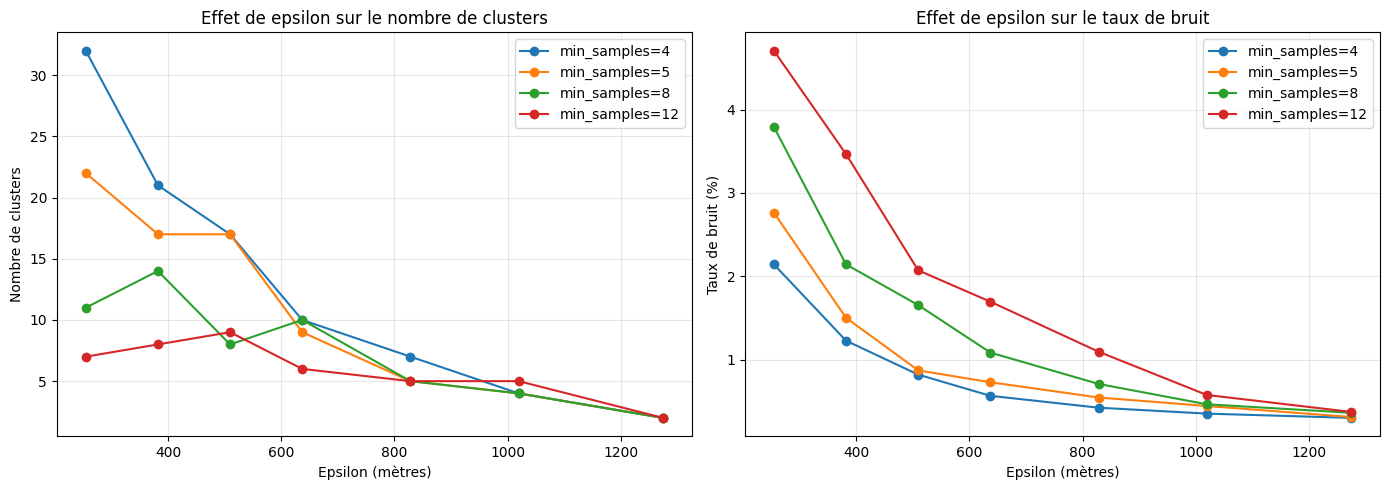

In [27]:
# ====================================================
# But : mesurer l'effet de epsilon et min_samples
# ====================================================
# Cette fonction exécute DBSCAN et renvoie 3 indicateurs faciles à lire :
# - nombre de clusters
# - nombre de points bruit
# - pourcentage de bruit
def evaluer_dbscan_haversine(coordonnees_rad, epsilon, min_echantillons):
    modele = DBSCAN(eps=epsilon, min_samples=min_echantillons, metric='haversine')
    etiquettes = modele.fit_predict(coordonnees_rad)

    masque_non_bruit = etiquettes != -1
    nb_clusters = len(set(etiquettes[masque_non_bruit])) if masque_non_bruit.any() else 0
    nb_bruit = int((etiquettes == -1).sum())
    taux_bruit_local = 100 * nb_bruit / len(etiquettes)

    return nb_clusters, nb_bruit, taux_bruit_local

# On définit une petite grille de test (du strict au permissif).
grille_epsilon = np.array([0.00004, 0.00006, 0.00008, 0.00010, 0.00013, 0.00016, 0.00020])
grille_min_echantillons = [4, 5, 8, 12]

# On teste chaque combinaison et on stocke tout dans un tableau.
lignes_resultats = []
for min_local in grille_min_echantillons:
    for eps_local in grille_epsilon:
        nb_clusters, nb_bruit, taux_bruit_local = evaluer_dbscan_haversine(
            coordonnees_rad, eps_local, min_local
        )
        lignes_resultats.append({
            'min_samples': min_local,
            'epsilon_rad': eps_local,
            'epsilon_metres': eps_local * 6371000,
            'nombre_clusters': nb_clusters,
            'nombre_bruit': nb_bruit,
            'taux_bruit_pct': taux_bruit_local
        })

table_sensibilite = pd.DataFrame(lignes_resultats)
display(table_sensibilite.head(12))

# =======================
# Graphique 1 + 2
# =======================
# Gauche : nombre de clusters selon epsilon.
# Droite : taux de bruit selon epsilon.
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
for min_local in grille_min_echantillons:
    sous_table = table_sensibilite[table_sensibilite['min_samples'] == min_local]
    axes[0].plot(
        sous_table['epsilon_metres'],
        sous_table['nombre_clusters'],
        marker='o',
        label=f'min_samples={min_local}'
    )
    axes[1].plot(
        sous_table['epsilon_metres'],
        sous_table['taux_bruit_pct'],
        marker='o',
        label=f'min_samples={min_local}'
    )

axes[0].set_title('Effet de epsilon sur le nombre de clusters')
axes[0].set_xlabel('Epsilon (mètres)')
axes[0].set_ylabel('Nombre de clusters')
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Effet de epsilon sur le taux de bruit')
axes[1].set_xlabel('Epsilon (mètres)')
axes[1].set_ylabel('Taux de bruit (%)')
axes[1].grid(True, alpha=0.3)

axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()

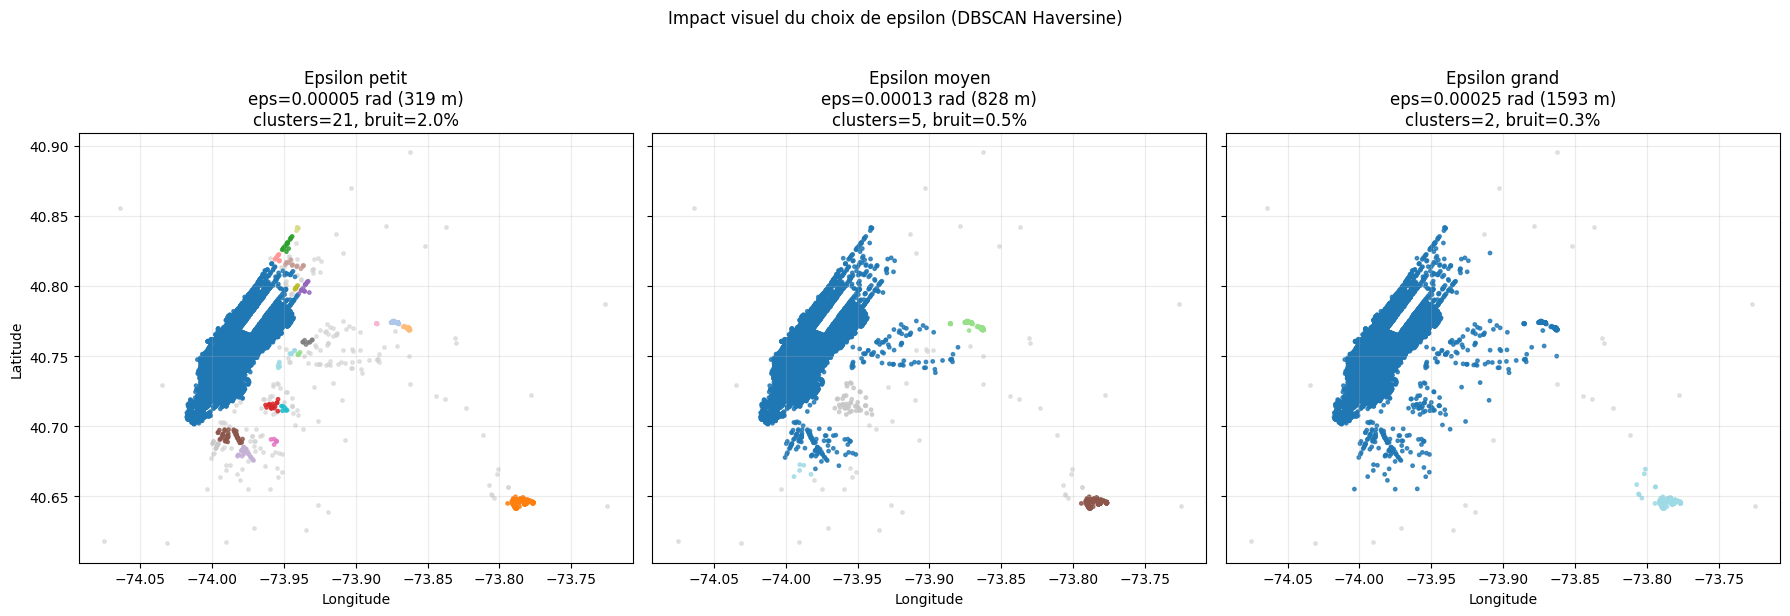

In [28]:
# =================================================================
# Visualisation finale : comparer 3 scénarios d'epsilon
# =================================================================
# Objectif pédagogique : voir "avec les yeux" l'effet d'epsilon.
parametres_comparaison = [
    ('Epsilon petit', 0.00005, 5),
    ('Epsilon moyen', 0.00013, 5),
    ('Epsilon grand', 0.00025, 5),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

for axe, (titre, eps_local, min_local) in zip(axes, parametres_comparaison):
    # On entraîne DBSCAN avec les paramètres du scénario.
    modele_local = DBSCAN(eps=eps_local, min_samples=min_local, metric='haversine')
    etiquettes_locales = modele_local.fit_predict(coordonnees_rad)

    # On repère les points bruit.
    masque_bruit_local = etiquettes_locales == -1

    # Bruit en gris pour qu'il ne domine pas la figure.
    axe.scatter(
        coordonnees_deg.loc[masque_bruit_local, 'pickup_longitude'],
        coordonnees_deg.loc[masque_bruit_local, 'pickup_latitude'],
        c='lightgray', s=6, alpha=0.6
    )

    # Clusters en couleur.
    axe.scatter(
        coordonnees_deg.loc[~masque_bruit_local, 'pickup_longitude'],
        coordonnees_deg.loc[~masque_bruit_local, 'pickup_latitude'],
        c=etiquettes_locales[~masque_bruit_local],
        cmap='tab20', s=6, alpha=0.8
    )

    # Petits indicateurs résumé dans le titre.
    nb_clusters_local = len(set(etiquettes_locales[~masque_bruit_local])) if (~masque_bruit_local).any() else 0
    taux_bruit_local = 100 * masque_bruit_local.mean()

    axe.set_title(
        f"{titre}\neps={eps_local:.5f} rad ({eps_local*6371000:.0f} m)\n"
        f"clusters={nb_clusters_local}, bruit={taux_bruit_local:.1f}%"
    )
    axe.grid(True, alpha=0.25)

axes[0].set_xlabel('Longitude')
axes[1].set_xlabel('Longitude')
axes[2].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
plt.suptitle('Impact visuel du choix de epsilon (DBSCAN Haversine)', y=1.02)
plt.tight_layout()
plt.show()

## Synthèse des réponses (Partie 6)

1. **Si `epsilon` est trop petit** : on fragmente la ville en beaucoup de petits clusters, et on classe davantage de points en bruit.
2. **Si `epsilon` est trop grand** : plusieurs zones différentes fusionnent en un petit nombre de gros clusters, la segmentation devient moins informative.
3. **Si `min_samples` augmente fortement** : il faut une densité locale plus forte pour former un cluster, donc le nombre de clusters diminue et le bruit augmente.
4. **Densités très différentes** : DBSCAN classique a des difficultés, car un seul `epsilon` global ne convient pas partout.
5. **Alternative recommandée** : `HDBSCAN`, qui gère mieux les densités hétérogènes.